*Notebook for learning JAX-MD and documenting observations.*

### Demo

The following code goes through the [JAX MD demo](https://colab.research.google.com/github/google/jax-md/blob/main/notebooks/talk_demo.ipynb).

#### Potential

In [1]:
# creating a soft-sphere potential
import jax.numpy as jnp

def soft_sphere(r):
    return jnp.where(
        r < 1.0,
        1/3 * (1 - r)**3,
        0.0
    )

print("Soft-sphere potential (r = 0.5):", soft_sphere(0.5))

Soft-sphere potential (r = 0.5): 0.041666668


Text(0, 0.5, 'V(r)')

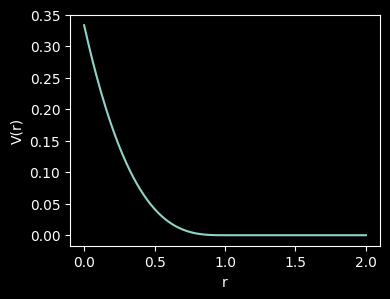

In [3]:
# plot of soft-sphere potential
import matplotlib.pyplot as plt
plt.style.use('dark_background')    # replace 'dark_background' with 'default' for light theme
plt.rcParams['figure.figsize'] = [4, 3]

r_series = jnp.linspace(0, 2.0, 200)
plt.plot(r_series, soft_sphere(r_series))

plt.xlabel("r")
plt.ylabel("V(r)")

In [4]:
from jax import grad

dv_dr = grad(soft_sphere)   # gradient of soft-sphere potential

print("Gradient of soft-sphere potential (r = 0.5):", dv_dr(0.5))

Gradient of soft-sphere potential (r = 0.5): -0.25


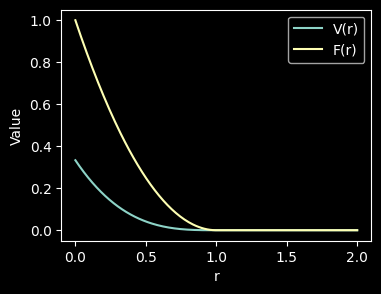

In [5]:
# we cannot implement dv_dr(r_series) directly because grad only works on scalar inputs
# so we use vmap to vectorize the gradient function
from jax import vmap

dv_dr_vec = vmap(dv_dr)

plt.plot(r_series, soft_sphere(r_series), label="V(r)")
plt.plot(r_series, -dv_dr_vec(r_series), label="F(r)")
plt.xlabel("r")
plt.ylabel("Value")
plt.legend()

#### System Initialization

In [6]:
from jax import random

key = random.PRNGKey(0)

num_particles = 128     # number of particles
dim = 2                 # 2D system

In [7]:
from jax_md.quantity import box_size_at_number_density

# number_density = N / V
box_size = box_size_at_number_density(particle_count = num_particles,
                                      number_density = 1.2,
                                      spatial_dimension = dim)

print("Box size:", box_size)                                    # calculates box size for a given desired number density of particles

R = random.uniform(key, (num_particles, dim), maxval=box_size)  # random initial positions of particles within the box

Box size: 10.327955


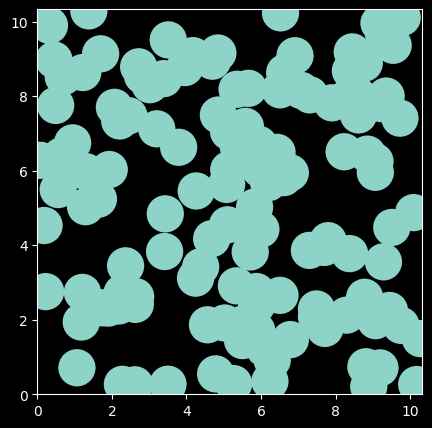

In [8]:
# matplotlib visualization of particle positions

fig, ax = plt.subplots(figsize=(5,5))

for r in R:
    circle = plt.Circle(r, radius=0.5, fill=True)
    ax.add_patch(circle)

ax.set_xlim(0, box_size)
ax.set_ylim(0, box_size)
ax.set_aspect('equal')
plt.show()

I think that Plotly might be a more interesting approach to visualizing our dynamics, and might be better for the long run, since it doesn't seem that JAX MD has a really good way of visualizing the dynamics if you're not using Colab. Plotly is interesting enough to learn, anyways, so I think it's worth the small time investment.

#### Plotly Digression

In [9]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

In [16]:
fig = go.Figure(
    data = go.Scatter(
        x=R[:,0],
        y=R[:,1],
        mode='markers'
    )
)
fig.update_layout(width=600, height=600)
fig.update_layout(template="plotly_dark")

fig.show()

In [25]:
import plotly.graph_objects as go

def plot_disks(R, radius=0.5, box_size=1.0, width=600, height=600):
    fig = go.Figure()

    # Add each circle as a shape
    for (x, y) in R:
        fig.add_shape(
            type="circle",
            x0=x - radius, x1=x + radius,
            y0=y - radius, y1=y + radius,
            line=dict(width=0),
            fillcolor="lightblue",   # or any color
            opacity=0.8
        )

    # Set view box
    view_box_delta = 0.05 * box_size
    fig.update_xaxes(range=[0 - view_box_delta, box_size + view_box_delta], scaleanchor="y", scaleratio=1, title="x")
    fig.update_yaxes(range=[0 - view_box_delta, box_size + view_box_delta], title="y")

    fig.update_layout(width=width, height=height, template="plotly_dark", title={
        "text": "Particle Positions",
        "x": 0.5,
        "xanchor": "center"
    })
    fig.show()

# Example
# R is an (N,2) array of positions
# box_size = 10.0
plot_disks(R, radius=0.5, box_size=box_size)


### Cookbook

The following code goes through the [JAX MD cookbook](https://colab.research.google.com/github/google/jax-md/blob/main/notebooks/jax_md_cookbook.ipynb).

In [1]:
# write something